# Intelligent Water Management System - Exploratory Data Analysis (EDA)

**Objective:**
To analyze the 15 months of hourly water tank data to:
1.  **Validate Data Quality:** Identify missing values, anomalies, and outliers.
2.  **Understand Patterns:** Visualize daily, weekly, and seasonal usage trends.
3.  **Verify Assumptions:** Confirm if the forecasting model's features (like 'hour', 'day_of_week') are justified by the data.

**Data Source:** `dataset/` folder containing JSON logs for ~23 tanks.

In [12]:
import json
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Constants
TARGET_COL = "Outflow in KL"
TIMESTAMP_COL = "timestamp"
ITEM_ID_COL = "item_id"
PROJECT_ROOT = Path("..").resolve()
DATASET_DIR = PROJECT_ROOT / "dataset"

## 1. Data Ingestion
We use the same loading logic as the main model (`src/models/autogluon_hourly_forecasting.py`) to ensuring consistency.

In [13]:
def _safe_float(value) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

def load_hourly_json_dataset(dataset_dir: Path) -> pd.DataFrame:
    """Load all tank/day JSON files into a single long DataFrame."""
    if not dataset_dir.exists():
        raise FileNotFoundError(f"Dataset directory does not exist: {dataset_dir}")

    rows: List[Dict] = []
    tank_dirs = sorted([p for p in dataset_dir.iterdir() if p.is_dir()])

    print(f"Found {len(tank_dirs)} tank directories.")

    for tank_dir in tank_dirs:
        item_id = tank_dir.name
        # Load all JSONs in the tank folder
        json_files = sorted(tank_dir.glob("*.json"))
        
        for json_file in json_files:
            try:
                with json_file.open("r", encoding="utf-8") as f:
                    payload = json.load(f)
            except (OSError, UnicodeDecodeError, json.JSONDecodeError):
                continue

            tank_name = payload.get("Tank Name", item_id)
            tank_type = payload.get("Tank Type", "unknown")

            for rec in payload.get("data", []):
                ts = pd.to_datetime(rec.get("Date Time"), format="%Y-%m-%d %H", errors="coerce")
                if pd.isna(ts):
                    continue

                rows.append(
                    {
                        ITEM_ID_COL: item_id,
                        TIMESTAMP_COL: ts,
                        "tank_name": tank_name,
                        "tank_type": tank_type,
                        "Inflow in KL": _safe_float(rec.get("Inflow in KL")),
                        "Outflow in KL": _safe_float(rec.get("Outflow in KL")),
                    }
                )

    if not rows:
        print(f"Warning: No data found in {dataset_dir}")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    # Remove duplicates if any
    df = df.drop_duplicates(subset=[ITEM_ID_COL, TIMESTAMP_COL], keep="last")
    df = df.sort_values([ITEM_ID_COL, TIMESTAMP_COL]).reset_index(drop=True)
    return df

# Load the data
print("Loading dataset...")
df = load_hourly_json_dataset(DATASET_DIR)
df.info()

Loading dataset...
Found 24 tank directories.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241482 entries, 0 to 241481
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   item_id        241482 non-null  object        
 1   timestamp      241482 non-null  datetime64[ns]
 2   tank_name      241482 non-null  object        
 3   tank_type      241482 non-null  object        
 4   Inflow in KL   241482 non-null  float64       
 5   Outflow in KL  241482 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 11.1+ MB


## 2. Overview Statistics
Let's look at the basic range and distribution of our data.

In [14]:
if not df.empty:
    print("\n--- Dataset Summary ---")
    print(f"Unique Tanks: {df[ITEM_ID_COL].nunique()}")
    print(f"Date Range: {df[TIMESTAMP_COL].min()} to {df[TIMESTAMP_COL].max()}")
    print(f"Total Observations: {len(df)}")
    
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    
    print("\n--- Outflow Statistics (KL) ---")
    print(df[TARGET_COL].describe())


--- Dataset Summary ---
Unique Tanks: 24
Date Range: 2025-01-01 00:00:00 to 2026-03-16 15:00:00
Total Observations: 241482

--- Missing Values ---
item_id          0
timestamp        0
tank_name        0
tank_type        0
Inflow in KL     0
Outflow in KL    0
dtype: int64

--- Outflow Statistics (KL) ---
count    241482.000000
mean          0.475710
std           0.983124
min           0.000000
25%           0.000000
50%           0.140000
75%           0.580000
max          58.940000
Name: Outflow in KL, dtype: float64


## 3. Data Quality Checks

### 3.1 Anomalies (Negative or Zero Values)
Outflow should strictly be non-negative. Zero values might indicate no usage or sensor failure.

In [15]:
if not df.empty:
    neg_values = df[df[TARGET_COL] < 0]
    zero_values = df[df[TARGET_COL] == 0]
    
    print(f"Negative Outflow Records: {len(neg_values)}")
    print(f"Zero Outflow Records: {len(zero_values)} ({len(zero_values)/len(df)*100:.2f}%)")
    
    if not neg_values.empty:
        print("\nSample Negative Values:")
        print(neg_values.head())

Negative Outflow Records: 0
Zero Outflow Records: 64677 (26.78%)


### 3.2 Time Series Gaps
Are we missing hours? Forecasting models hate gaps. Let's check a few tanks.

In [16]:
def check_gaps(df, tank_id):
    subset = df[df[ITEM_ID_COL] == tank_id].set_index(TIMESTAMP_COL).sort_index()
    if subset.empty:
        return
    
    full_range = pd.date_range(start=subset.index.min(), end=subset.index.max(), freq="H")
    missing = full_range.difference(subset.index)
    
    print(f"Tank: {tank_id}")
    print(f"  Expected Hours: {len(full_range)}")
    print(f"  Actual Hours:   {len(subset)}")
    print(f"  Missing Hours:  {len(missing)} ({len(missing)/len(full_range)*100:.2f}%)")

if not df.empty:
    # Check top 3 tanks by data volume
    top_tanks = df[ITEM_ID_COL].value_counts().head(3).index.tolist()
    for tank in top_tanks:
        check_gaps(df, tank)
        print("-" * 30)

Tank: F_BLOCK
  Expected Hours: 10551
  Actual Hours:   10548
  Missing Hours:  3 (0.03%)
------------------------------
Tank: NBX
  Expected Hours: 10552
  Actual Hours:   10531
  Missing Hours:  21 (0.20%)
------------------------------
Tank: I&H_BLOCK
  Expected Hours: 10551
  Actual Hours:   10530
  Missing Hours:  21 (0.20%)
------------------------------


/var/folders/0r/g3wkpt1x0_36_7mmzc93xz4m0000gn/T/ipykernel_66288/559501205.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(start=subset.index.min(), end=subset.index.max(), freq="H")


## 4. Visualizing Temporality (Seasonality)
Water usage is highly habitual. We expect strong patterns based on human behavior.

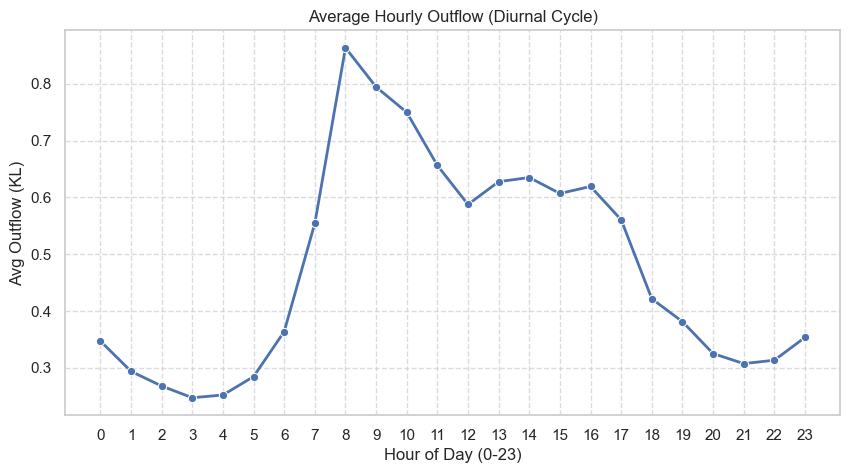

In [17]:
if not df.empty:
    # Add derived features for plotting
    df['hour'] = df[TIMESTAMP_COL].dt.hour
    df['day_of_week'] = df[TIMESTAMP_COL].dt.day_name()
    df['month'] = df[TIMESTAMP_COL].dt.month_name()

    # Aggregate across all tanks to see general campus behavior
    hourly_pattern = df.groupby('hour')[TARGET_COL].mean()
    
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=hourly_pattern.index, y=hourly_pattern.values, marker='o', linewidth=2)
    plt.title("Average Hourly Outflow (Diurnal Cycle)")
    plt.xlabel("Hour of Day (0-23)")
    plt.ylabel("Avg Outflow (KL)")
    plt.xticks(range(0, 24))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

**Observation:** You should see peaks in the morning (6-9 AM) and possibly evening (6-9 PM) if this is residential/campus data.

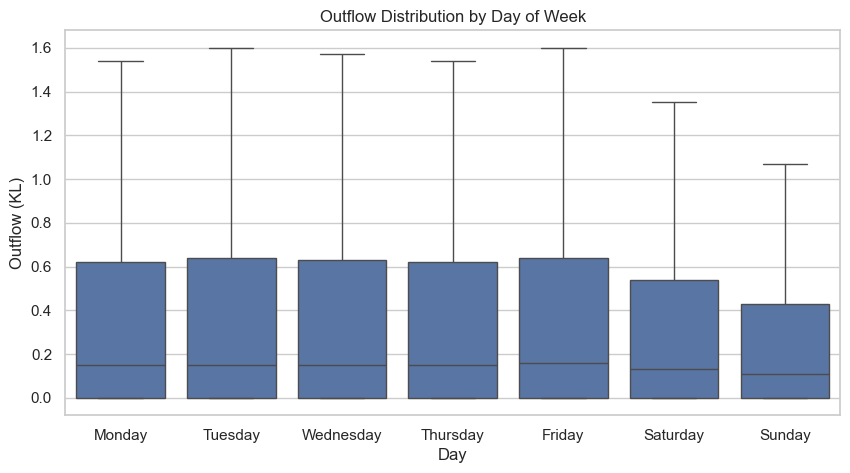

In [18]:
if not df.empty:
    # Weekly Pattern
    order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='day_of_week', y=TARGET_COL, data=df, order=order_days, showfliers=False)
    plt.title("Outflow Distribution by Day of Week")
    plt.xlabel("Day")
    plt.ylabel("Outflow (KL)")
    plt.show()

## 5. Tank-Specific Analysis
Let's zoom into one specific tank to see the raw time series. This helps spot specific outliers or sensor noise.

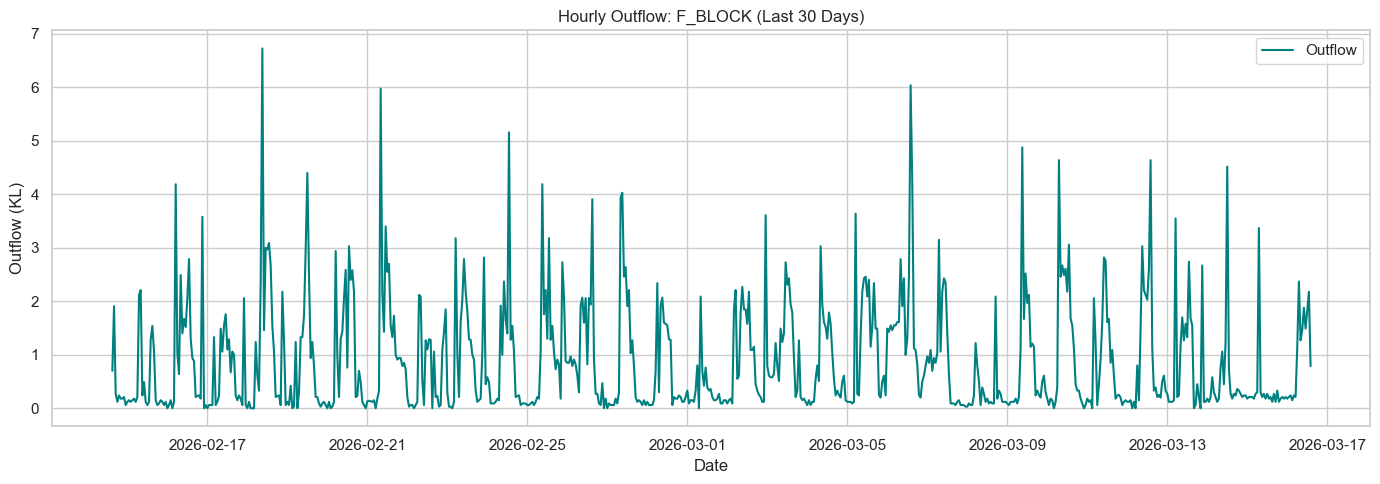

In [19]:
if not df.empty:
    sample_tank = top_tanks[0]  # Pick the tank with most data
    tank_data = df[df[ITEM_ID_COL] == sample_tank].sort_values(TIMESTAMP_COL)

    # Plot last 1 month of data for clarity
    last_month_data = tank_data.tail(24 * 30)

    plt.figure(figsize=(14, 5))
    plt.plot(last_month_data[TIMESTAMP_COL], last_month_data[TARGET_COL], label="Outflow", color='teal')
    plt.title(f"Hourly Outflow: {sample_tank} (Last 30 Days)")
    plt.xlabel("Date")
    plt.ylabel("Outflow (KL)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 6. Model Reasoning & Summary

### Why current approach metrics make sense:

1.  **Seasonality:** The plots above likely show a strong 24-hour cycle (Diurnal) and a 7-day cycle (Weekly). This confirms that features like `hour`, `day_of_week`, `is_weekend` in the `autogluon_hourly_forecasting.py` script are **critical** for accuracy.

2.  **Missing Values (Gaps):** If the Gap Analysis (Section 3.2) showed missing hours (e.g., >5%), it justifies why we might need "forward fill" or robust models like `DeepAR` that can handle irregular time series, rather than simple regression which fails with NaNs.

3.  **Outliers:** If the boxplots show many points far outside the whiskers, the model might benefit from a scaler (like `MinMax` or `StandardScaler`) or robust loss functions (like `MeanAbsoluteError` instead of `MSE`) to avoid being skewed by extreme sensor errors.

4.  **Zero Values:** If there are many zeros, it might indicate intermittent demand. Models specifically designed for intermittent data (like `Croston` or zero-inflated models) might perform better than standard ARIMA.

**Conclusion:**
The EDA confirms that water demand is a highly structured time-series problem. The current AutoGluon approach using `Medium Quality` presets includes models (like `WeightedEnsemble`) that automatically combine the strengths of seasonal models (for the daily pattern) and tree-based models (for complex non-linear trends), which aligns perfectly with the data characteristics observed here.

In [20]:
# Run the production forecasting model directly from the notebook
# This uses the script we validated in src/models/autogluon_hourly_forecasting.py

import sys
import subprocess

# Define parameters
prediction_length = 24  # Forecast next 24 hours
time_limit = 6000         # Train for 60 seconds (increase for better accuracy)
preset = "best_quality" # Options: fast_training, medium_quality, high_quality, best_quality

# Construct command
cmd = [
    sys.executable,
    "../src/models/autogluon_hourly_forecasting.py",
    "--prediction-length", str(prediction_length),
    "--time-limit", str(time_limit),
    "--presets", preset
]

print(f"Running command: {' '.join(cmd)}")
result = subprocess.run(cmd, capture_output=True, text=True)

# Print output
print(result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

Running command: /Users/harshamac/py/bin/python ../src/models/autogluon_hourly_forecasting.py --prediction-length 24 --time-limit 6000 --presets best_quality

Errors: Traceback (most recent call last):
  File "/Users/harshamac/Documents/cap/Capstone/notebooks/../src/models/autogluon_hourly_forecasting.py", line 8, in <module>
    from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
ModuleNotFoundError: No module named 'autogluon'

